# Assignment - Unsupervise Learning
In this assignment, we apply clustering and dimension reduction on Breast Cancer dataset from scikit-learn.
We will explore:

1. **Clustering**: find potential group in the data.
2. **PCA**: reduce feature dimensions while keeping important information
3. **Model comparison**: check performance before and after PCA

## 1. Introduction & Setup
1. Load Breast Cancer dataset from scikit-learn.
2. Understand and explore the data.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load data as a DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Unsupervised Learning Task: Clustering

#### Separate features (X) and target (Y), find potential groups on input features (X) using k-means.

Clustering algorithms are scale-sensitive, so normalize data first.

In [30]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

#### TODO: 
1. Build k-means model.
2. Evaluate through SSE or Silhouette and visualize it.
3. Find `K` for k-means

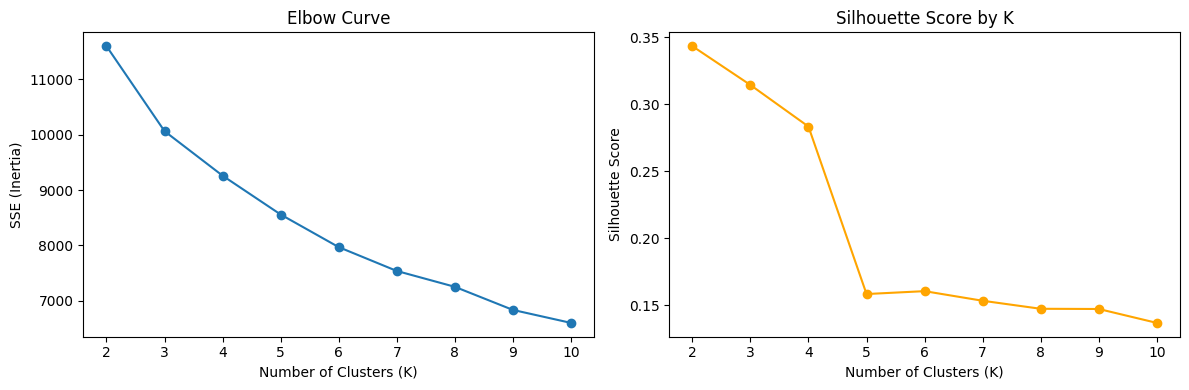

Chosen K (best silhouette): 2
Best silhouette score: 0.3434
Adjusted Rand Index vs true labels: 0.6536


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

sse = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_norm)
    sse.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_norm, labels))

best_k = K_range[np.argmax(silhouette_scores)]
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_norm)
ari = adjusted_rand_score(y, cluster_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot (SSE)
axes[0].plot(K_range, sse, marker='o')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('SSE (Inertia)')
axes[0].set_title('Elbow Curve')

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

print(f'Chosen K (best silhouette): {best_k}')
print(f'Best silhouette score: {max(silhouette_scores):.4f}')
print(f'Adjusted Rand Index vs true labels: {ari:.4f}')

## Supervised Learning Task: Classification with/without dimension reduction

#### Step1: Split into train/test and normalize.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train_scaled.shape)
print('Test shape :', X_test_scaled.shape)
print('Shown shape: (ROWS, COLS)')

Train shape: (455, 30)
Test shape : (114, 30)
Shown shape: (ROWS, COLS)


#### Step 2: Apply PCA on input data

TODO:
1. Fit PCA on normalized training data.
2. Visualize the importance of principal components though scree plot.
3. Transform train/test data to reduced dimensions.

Components needed for >=95% variance: 10


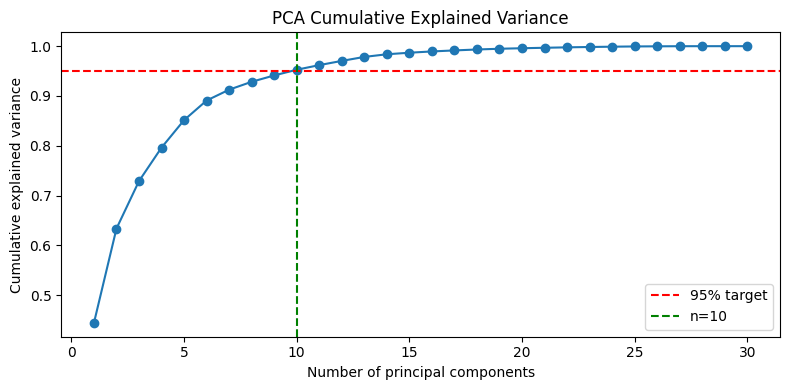

Original train shape: (455, 30)
PCA train shape     : (455, 10)


In [33]:
from sklearn.decomposition import PCA

# Fit PCA on normalized training data
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative explained variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1

print(f'Components needed for >=95% variance: {n_components_95}')

# Scree-style cumulative variance plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% target')
plt.axvline(n_components_95, color='green', linestyle='--', label=f'n={n_components_95}')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

# Fit PCA with selected number of components and transform data
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Original train shape:', X_train_scaled.shape)
print('PCA train shape     :', X_train_pca.shape)

#### Step 3: Classification before and after PCA
Train a classifier (e.g. Logistic Regression, Random Forest, etc) on:
1. Original scaled features
2. PCA-reduced features
Then compare test accuracy.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train on original scaled features
model_original = LogisticRegression(max_iter=1000, random_state=42)
model_original.fit(X_train_scaled, y_train)
y_pred_original = model_original.predict(X_test_scaled)
acc_original = accuracy_score(y_test, y_pred_original)

# Train on PCA-reduced features
model_pca = LogisticRegression(max_iter=1000, random_state=42)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f'Accuracy (original features): {acc_original:.4f}')
print(f'Accuracy (PCA features)     : {acc_pca:.4f}')

print('\nClassification report (PCA model):')
print(classification_report(y_test, y_pred_pca))

Accuracy (original features): 0.9825
Accuracy (PCA features)     : 0.9737

Classification report (PCA model):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Questions
Answer briefly:
1. Which `K` did you choose for K-Means, and why?
2. How many principal components were needed for 95% variance?
3. Did PCA improve or reduce the test accuracy? Why might that happen?
4. Why did we normalize data before K-means and PCA?

## Answers

1. Which K did you choose for K Means, and why?
- I chose K equals 2 as the final choice because it has the highest silhouette score, which means better cluster separation.
- I also considered K equals 3 from the elbow perspective, since the SSE curve starts bending around there.
- So both K=2 and K=3 are defendable, but I prioritized silhouette and kept K=2.

2. How many principal components were needed for 95 percent variance?
- 10 principal components.

3. Did PCA improve or reduce test accuracy, and why?
- It reduced test accuracy slightly in this run.
- Original scaled features accuracy: 0.9825
- PCA features accuracy: 0.9737
- This can happen because PCA is unsupervised and can remove some variance that still helps class separation.

4. Why normalize data before K means and PCA?
- Both K means and PCA are scale sensitive.
- Without normalization, larger scale features dominate distances and component directions, which can bias clustering and PCA results.